# Beverage Stain Classification Using Machine Learning and Deep Learning

## Step 1: Import Required Libraries

In [2]:
# General Libraries
import numpy as np
import pandas as pd
import time

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Performance Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Conv1D,
    MaxPooling1D,
    Flatten,
    LSTM
)
from tensorflow.keras.utils import to_categorical

In [3]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Reshape

## Step 2: Load the Dataset

In [4]:
file_path = r"../data/Beverage_Dataset.csv"

df = pd.read_csv(file_path)

C:\Users\devip\AppData\Local\Temp\ipykernel_20196\948438028.py:3: DtypeWarning: Columns (8,12,13,18,20,90,91,92,93,94,97,131,144,145,149,150,156,158,159,160,163,164,165,168,169,171,173,174,176,177,178,179,180,181,183,184,185,189,191,192,193,195,196,198,199,200,201,202,203,204) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


## Step 3: Explore the Dataset

In [3]:
df

,Unnamed: 0,1,2,3,4,5,6,7,8,9,...,196,197,198,199,200,201,202,203,204,205
0,0,0.406780,0.362319,0.325000,0.271739,0.245283,0.211864,0.194030,0.189189,0.165644,...,0.32948,0.339394,0.343949,0.342282,0.35461,0.345865,0.346774,0.355932,0.380435,1
1,1,0.413793,0.367647,0.303797,0.271739,0.238095,0.220339,0.194030,0.175676,0.160494,...,0.33526,0.347561,0.352564,0.348993,0.368794,0.37594,0.376,0.364407,0.391304,1
2,2,0.423729,0.347826,0.303797,0.282609,0.228571,0.218487,0.208955,0.182432,0.165644,...,0.369942,0.363636,0.375796,0.375839,0.382979,0.390977,0.395161,0.386555,0.402174,1
3,3,0.413793,0.362319,0.312500,0.263736,0.238095,0.218487,0.194030,0.175676,0.166667,...,0.387283,0.381818,0.388535,0.398649,0.392857,0.393939,0.41129,0.411765,0.423913,1
4,4,0.379310,0.347826,0.300000,0.274725,0.235849,0.210084,0.186567,0.175676,0.159509,...,0.385057,0.393939,0.394904,0.395973,0.397163,0.406015,0.416,0.420168,0.430108,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121490,121490,0.673469,0.660714,0.651515,0.671053,0.643678,0.663265,0.678899,0.689076,0.696970,...,0.755556,0.744186,0.739837,0.767241,0.754545,0.72381,0.752577,0.741935,0.756757,9
121491,121491,0.693878,0.660714,0.651515,0.684211,0.689655,0.693878,0.669725,0.697479,0.717557,...,0.755556,0.751938,0.745902,0.758621,0.761468,0.733333,0.752577,0.763441,0.756757,9
121492,121492,0.673469,0.660714,0.666667,0.644737,0.655172,0.653061,0.678899,0.697479,0.696970,...,0.742647,0.728682,0.747968,0.758621,0.745455,0.72381,0.742268,0.76087,0.743243,9
121493,121493,0.645833,0.642857,0.651515,0.640000,0.643678,0.653061,0.660551,0.680672,0.674242,...,0.727941,0.728682,0.721311,0.724138,0.727273,0.72381,0.734694,0.75,0.716216,9


In [4]:
df.shape

(121495, 206)

In [5]:
df.columns

Index(['Unnamed: 0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '196', '197', '198', '199', '200', '201', '202', '203', '204', '205'],
      dtype='object', length=206)

## Step 4: Data Preprocessing

In [5]:
df = df.drop(columns=["Unnamed: 0"])

In [6]:
df.shape

(121495, 205)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121495 entries, 0 to 121494
Columns: 205 entries, 1 to 205
dtypes: float64(154), int64(1), object(50)
memory usage: 190.0+ MB


In [8]:
df.dtypes

1      float64
2      float64
3      float64
4      float64
5      float64
        ...   
201     object
202     object
203     object
204     object
205      int64
Length: 205, dtype: object

In [9]:
df.iloc[:, 150:156]

,151,152,153,154,155,156
0,0.294679,0.297486,0.293276,0.297376,0.300595,0.300912
1,0.308322,0.310056,0.312857,0.309038,0.311012,0.305936
2,0.320600,0.327273,0.330472,0.325073,0.328380,0.328767
3,0.343793,0.344056,0.346209,0.344023,0.349183,0.348554
4,0.354707,0.356643,0.357143,0.359534,0.360119,0.354642
...,...,...,...,...,...,...
121490,0.753086,0.756318,0.750923,0.747646,0.763462,0.760314
121491,0.761484,0.754069,0.754613,0.759398,0.773077,0.759842
121492,0.751323,0.752708,0.760148,0.755639,0.757692,0.760314
121493,0.734982,0.734657,0.735675,0.729323,0.738462,0.738703


In [10]:
df.iloc[:, :-1] = df.iloc[:, :-1].apply(pd.to_numeric, errors="coerce")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121495 entries, 0 to 121494
Columns: 205 entries, 1 to 205
dtypes: float64(154), int64(1), object(50)
memory usage: 190.0+ MB


In [12]:
print(df["155"].map(type).value_counts())

155
<class 'float'>    121495
Name: count, dtype: int64


In [13]:
print(df["155"].head(10).tolist())

[0.30059522, 0.3110119, 0.32838038, 0.34918275, 0.36011904, 0.38930163, 0.448737, 0.5342262, 0.65029764, 0.7206538]


In [14]:
object_columns = df.select_dtypes(include=["object"]).columns

print(object_columns)

Index(['8', '12', '13', '18', '20', '90', '91', '92', '93', '94', '97', '131',
       '144', '145', '149', '150', '156', '158', '159', '160', '163', '164',
       '165', '168', '169', '171', '173', '174', '176', '177', '178', '179',
       '180', '181', '183', '184', '185', '189', '191', '192', '193', '195',
       '196', '198', '199', '200', '201', '202', '203', '204'],
      dtype='object')


In [15]:
print(repr(df["8"].iloc[0]))
print(type(df["8"].iloc[0]))

0.1891892
<class 'float'>


In [16]:
print(repr(df["90"].iloc[0]))
print(type(df["90"].iloc[0]))

0.24190477
<class 'float'>


## Step 5: Feature and Target Separation

In [17]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(X.dtypes.value_counts())

float64    154
object      50
Name: count, dtype: int64


In [18]:
print(df["8"].dtype)
print(df["8"].apply(type).value_counts())

object
8
<class 'float'>    121495
Name: count, dtype: int64


In [19]:
print(df["12"].dtype)
print(df["12"].apply(type).value_counts())

object
12
<class 'float'>    121495
Name: count, dtype: int64


In [20]:
feature_columns = df.columns[:-1]

df[feature_columns] = df[feature_columns].astype("float64")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121495 entries, 0 to 121494
Columns: 205 entries, 1 to 205
dtypes: float64(204), int64(1)
memory usage: 190.0 MB


## Check for Missing Values

In [22]:
df.isnull().sum()

1         0
2         0
3         0
4         0
5         0
       ... 
201       4
202       2
203       3
204    4138
205       0
Length: 205, dtype: int64

##  Handle Missing Values

In [23]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [24]:
df.isnull().sum()

1      0
2      0
3      0
4      0
5      0
      ..
201    0
202    0
203    0
204    0
205    0
Length: 205, dtype: int64

## Separate Features and Labels

In [25]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [26]:
print("Features Shape :", X.shape)
print("Labels Shape   :", y.shape)

Features Shape : (121495, 204)
Labels Shape   : (121495,)


## Step 6: Split the Dataset

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (97196, 204)
Testing Features  : (24299, 204)
Training Labels   : (97196,)
Testing Labels    : (24299,)


###  Verify Class Distribution

In [30]:
print("Original Dataset:")
print(y.value_counts().sort_index())

print("\nTraining Dataset:")
print(y_train.value_counts().sort_index())

print("\nTesting Dataset:")
print(y_test.value_counts().sort_index())

Original Dataset:
205
1    13500
2    13561
3    13500
4    13501
5    13502
6    13502
7    13427
8    13501
9    13501
Name: count, dtype: int64

Training Dataset:
205
1    10800
2    10849
3    10800
4    10801
5    10801
6    10801
7    10742
8    10801
9    10801
Name: count, dtype: int64

Testing Dataset:
205
1    2700
2    2712
3    2700
4    2700
5    2701
6    2701
7    2685
8    2700
9    2700
Name: count, dtype: int64


## Step 7: Feature Scaling

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [32]:
print("Training Data Shape :", X_train_scaled.shape)
print("Testing Data Shape  :", X_test_scaled.shape)

Training Data Shape : (97196, 204)
Testing Data Shape  : (24299, 204)


###  Verify Standardization

In [33]:
print("Mean of first feature:", X_train_scaled[:, 0].mean())
print("Standard Deviation of first feature:", X_train_scaled[:, 0].std())

Mean of first feature: 1.5878213322265706e-16
Standard Deviation of first feature: 1.0


## Step 8: ANOVA Feature Selection

In [34]:
anova_selector = SelectKBest(score_func=f_classif, k="all")

anova_selector.fit(X_train_scaled, y_train)

,score_func,<function f_c...002A7A09503A0>
,k,'all'


### Display and Rank ANOVA Feature Scores

In [35]:
feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "F_score": anova_selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="F_score",
    ascending=False
)

feature_scores.head(20)

,Feature,F_score
8,9,2513.697453
7,8,2504.996640
9,10,2496.972132
6,7,2481.037060
10,11,2465.879562
5,6,2423.351608
11,12,2412.276983
4,5,2353.310039
12,13,2352.273859
13,14,2274.166959


## Step 9: Hyperparameter Tuning- ANOVA(Best k)

In [36]:
k_values = [20, 40, 60, 80, 100, 120, 140, 160, 180, 204]

cv_accuracies = []

### Determine the Optimal Value of k using MLP and 5-Fold Cross Validation

In [39]:
for k in k_values:

    print(f"\nTesting k = {k}")

    # Select top k features
    anova_selector = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_selected = anova_selector.fit_transform(
        X_train_scaled,
        y_train
    )

    # Create MLP Classifier
    mlp = MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=300,
        random_state=42
    )

    # Perform 5-Fold Cross Validation
    scores = cross_val_score(
        mlp,
        X_train_selected,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    # Calculate average accuracy
    mean_accuracy = scores.mean()

    # Store accuracy
    cv_accuracies.append(mean_accuracy)

    print(f"Average Accuracy = {mean_accuracy:.4f}")


Testing k = 20
Average Accuracy = 0.5176

Testing k = 40
Average Accuracy = 0.7126

Testing k = 60
Average Accuracy = 0.8120

Testing k = 80
Average Accuracy = 0.8759

Testing k = 100
Average Accuracy = 0.8817

Testing k = 120
Average Accuracy = 0.8819

Testing k = 140
Average Accuracy = 0.8920

Testing k = 160
Average Accuracy = 0.8982

Testing k = 180
Average Accuracy = 0.8974

Testing k = 204
Average Accuracy = 0.9060


In [34]:
results_df = pd.DataFrame({
    "k": k_values,
    "Average_Accuracy": cv_accuracies
})

results_df["Accuracy (%)"] = results_df["Average_Accuracy"] * 100

results_df

ValueError: All arrays must be of the same length

In [41]:
print(len(k_values))
print(len(cv_accuracies))

10
14


In [42]:
cv_accuracies

[np.float64(0.5176036872334835),
 np.float64(0.712560263963857),
 np.float64(0.812029263961105),
 np.float64(0.8758796907578568),
 np.float64(0.5176036872334835),
 np.float64(0.712560263963857),
 np.float64(0.812029263961105),
 np.float64(0.8758796907578568),
 np.float64(0.8816514735236977),
 np.float64(0.8819395224313602),
 np.float64(0.8920121443527999),
 np.float64(0.8981851114079138),
 np.float64(0.8974443801936498),
 np.float64(0.9060042642627767)]

In [43]:
cv_accuracies = [
    0.5176036872334835,
    0.712560263963857,
    0.812029263961105,
    0.8758796907578568,
    0.8816514735236977,
    0.8819395224313602,
    0.8920121443527999,
    0.8981851114079138,
    0.8974443801936498,
    0.9060042642627767
]

In [44]:
print(len(k_values))
print(len(cv_accuracies))

10
10


In [45]:
results_df = pd.DataFrame({
    "k": k_values,
    "Average Accuracy": cv_accuracies
})

results_df["Accuracy (%)"] = results_df["Average Accuracy"] * 100

results_df

,k,Average Accuracy,Accuracy (%)
0,20,0.517604,51.760369
1,40,0.712560,71.256026
2,60,0.812029,81.202926
3,80,0.875880,87.587969
4,100,0.881651,88.165147
5,120,0.881940,88.193952
6,140,0.892012,89.201214
7,160,0.898185,89.818511
8,180,0.897444,89.744438
9,204,0.906004,90.600426


In [46]:
results_df.to_csv("../reports/k_search_results_round1.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


## Refined Search for the Optimal Value of k

In [50]:
k_values = [185, 190, 195, 200]

cv_accuracies = []

In [51]:
for k in k_values:

    print(f"\nTesting k = {k}")

    # Select top k features
    anova_selector = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_selected = anova_selector.fit_transform(
        X_train_scaled,
        y_train
    )

    # Create MLP Classifier
    mlp = MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=300,
        random_state=42
    )

    # Perform 5-Fold Cross Validation
    scores = cross_val_score(
        mlp,
        X_train_selected,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    # Calculate average accuracy
    mean_accuracy = scores.mean()

    # Store accuracy
    cv_accuracies.append(mean_accuracy)

    print(f"Average Accuracy = {mean_accuracy:.4f}")


Testing k = 185
Average Accuracy = 0.8891

Testing k = 190
Average Accuracy = 0.8989

Testing k = 195
Average Accuracy = 0.9040

Testing k = 200
Average Accuracy = 0.9057


##  Combine Round 1 and Round 2 Results

In [52]:
round1_df = pd.read_csv("../reports/k_search_results_round1.csv")

round2_df = pd.DataFrame({
    "k": [185, 190, 195, 200],
    "Average Accuracy": cv_accuracies
})

round2_df["Accuracy (%)"] = round2_df["Average Accuracy"] * 100

In [53]:
final_results_df = pd.concat(
    [round1_df, round2_df],
    ignore_index=True
)

final_results_df = final_results_df.sort_values("k").reset_index(drop=True)

final_results_df

,k,Average Accuracy,Accuracy (%)
0,20,0.517604,51.760369
1,40,0.712560,71.256026
2,60,0.812029,81.202926
3,80,0.875880,87.587969
4,100,0.881651,88.165147
5,120,0.881940,88.193952
6,140,0.892012,89.201214
7,160,0.898185,89.818511
8,180,0.897444,89.744438
9,185,0.889110,88.911048


In [55]:
final_results_df.to_csv(
    "../reports/final_k_search_results.csv",
    index=False
)

print("Final k search results saved successfully!")

Final k search results saved successfully!


## Final Refinement of k Values

In [56]:
k_values = [165, 170, 175]

cv_accuracies = []

In [57]:
for k in k_values:

    print(f"\nTesting k = {k}")

    # Select top k features
    anova_selector = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_selected = anova_selector.fit_transform(
        X_train_scaled,
        y_train
    )

    # Create MLP Classifier
    mlp = MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=300,
        random_state=42
    )

    # Perform 5-Fold Cross Validation
    scores = cross_val_score(
        mlp,
        X_train_selected,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    # Calculate average accuracy
    mean_accuracy = scores.mean()

    # Store accuracy
    cv_accuracies.append(mean_accuracy)

    print(f"Average Accuracy = {mean_accuracy:.4f}")


Testing k = 165
Average Accuracy = 0.8922

Testing k = 170
Average Accuracy = 0.8985

Testing k = 175
Average Accuracy = 0.8993


##  Store Final k Search Results

In [58]:
final_results_df = pd.DataFrame({
    "k": [20, 40, 60, 80, 100, 120, 140, 160,
          165, 170, 175,
          180, 185, 190, 195, 200, 204],

    "Average Accuracy": [
        0.5176036872334835,
        0.7125602639638570,
        0.8120292639611050,
        0.8758796907578568,
        0.8816514735236977,
        0.8819395224313602,
        0.8920121443527999,
        0.8981851114079138,
        0.8922,
        0.8985,
        0.8993,
        0.8974443801936498,
        0.8891,
        0.8989,
        0.9040,
        0.9057,
        0.9060042642627767
    ]
})

final_results_df["Accuracy (%)"] = final_results_df["Average Accuracy"] * 100

final_results_df = final_results_df.sort_values("k").reset_index(drop=True)

final_results_df

,k,Average Accuracy,Accuracy (%)
0,20,0.517604,51.760369
1,40,0.712560,71.256026
2,60,0.812029,81.202926
3,80,0.875880,87.587969
4,100,0.881651,88.165147
5,120,0.881940,88.193952
6,140,0.892012,89.201214
7,160,0.898185,89.818511
8,165,0.892200,89.220000
9,170,0.898500,89.850000


In [59]:
final_results_df.to_csv("../reports/k_search_results.csv", index=False)

print("Final k search results saved successfully!")

Final k search results saved successfully!


## Step 10: Select the Final Features

In [37]:
best_k = 204

print(f"Final Selected k = {best_k}")
print("Average Cross-Validation Accuracy = 90.60%")

Final Selected k = 204
Average Cross-Validation Accuracy = 90.60%


In [38]:
best_k = 204

final_selector = SelectKBest(
    score_func=f_classif,
    k=best_k
)

X_train_selected = final_selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_selected = final_selector.transform(
    X_test_scaled
)

In [39]:
print("Selected Training Features :", X_train_selected.shape)
print("Selected Testing Features  :", X_test_selected.shape)

Selected Training Features : (97196, 204)
Selected Testing Features  : (24299, 204)


# Step 11: Model Evaluation Function

In [40]:
class_names = [
    "Papaya",
    "Coffee",
    "Pomegranate",
    "Orange",
    "Tea",
    "Wine",
    "Whisky",
    "Rum",
    "Brandy"
]

In [39]:
results = []

In [40]:
def evaluate_model(model_name,
                   model,
                   X_test,
                   y_test,
                   training_time):

    # Prediction Time
    start_time = time.time()
    y_pred = model.predict(X_test)
    prediction_time = time.time() - start_time

    # Performance Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
    )

    recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
    )

    f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
    )

    # Store Results (store as percentages)
    results.append({
        "Model": model_name,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1 Score (%)": f1 * 100,
        "Training Time (sec)": training_time,
        "Prediction Time (sec)": prediction_time
    })

    # Print Summary
    print("=" * 70)
    print(f"{model_name} Completed Successfully")
    print("=" * 70)

    print(f"Accuracy          : {accuracy*100:.2f}%")
    print(f"Precision (Macro) : {precision*100:.2f}%")
    print(f"Recall (Macro)    : {recall*100:.2f}%")
    print(f"F1 Score (Macro)  : {f1*100:.2f}%")
    print(f"Training Time     : {training_time:.4f} sec")
    print(f"Prediction Time   : {prediction_time:.4f} sec")

    # Classification Report
    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

# Machine Learning Models

## Step 12: Logistic Regression

In [43]:
start_time = time.time()

logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42 
)

logistic_model.fit(
    X_train_selected,
    y_train
)

training_time = time.time() - start_time

Logistic Regression Completed Successfully
Accuracy          : 65.89%
Precision (Macro) : 66.23%
Recall (Macro)    : 65.87%
F1 Score (Macro)  : 65.52%
Training Time     : 657.4583 sec
Prediction Time   : 0.0410 sec

Classification Report:

              precision    recall  f1-score   support

      Papaya     0.9502    0.8133    0.8765      2700
      Coffee     0.7529    0.6438    0.6941      2712
 Pomegranate     0.7010    0.8959    0.7865      2700
      Orange     0.8357    0.7763    0.8049      2700
         Tea     0.6615    0.6846    0.6729      2701
        Wine     0.5546    0.6016    0.5772      2701
      Whisky     0.4399    0.2819    0.3436      2685
         Rum     0.4965    0.6070    0.5462      2700
      Brandy     0.5683    0.6237    0.5947      2700

    accuracy                         0.6589     24299
   macro avg     0.6623    0.6587    0.6552     24299
weighted avg     0.6625    0.6589    0.6554     24299



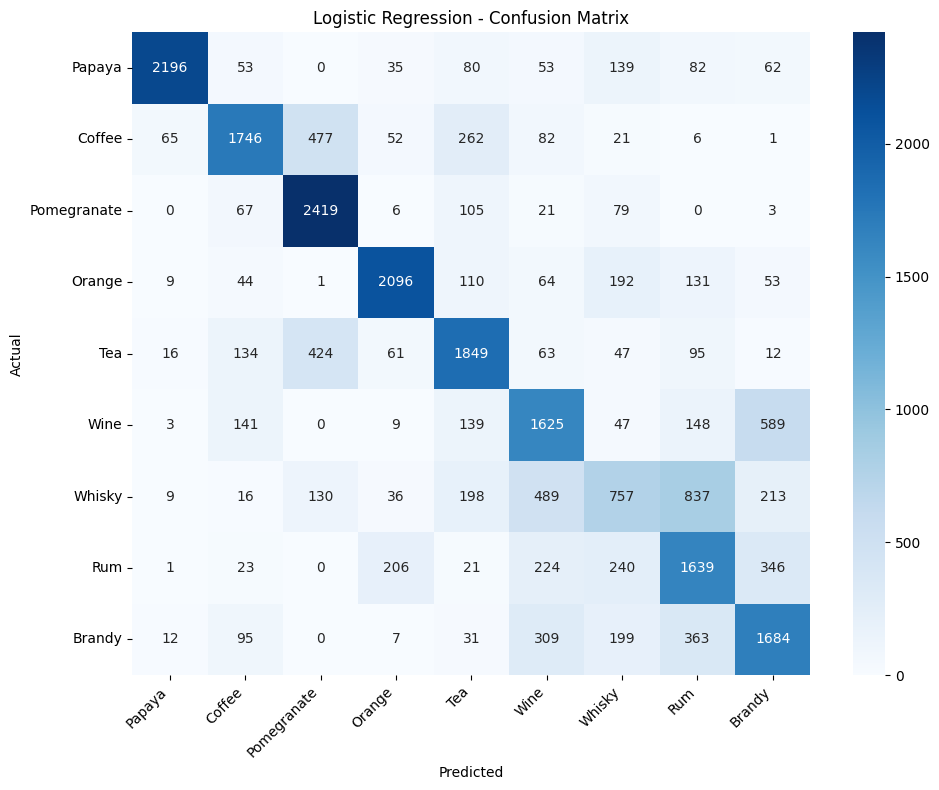

In [44]:
evaluate_model(
    model_name="Logistic Regression",
    model=logistic_model,
    X_test=X_test_selected,
    y_test=y_test,
    training_time=training_time
)

## Step 13: K-Nearest Neighbors (KNN)

### Find the Optimal Number of Neighbors for KNN

In [45]:
n_neighbors = [1, 3, 5, 7, 9, 11, 13, 15]

In [46]:
neighbor_values = [1, 3, 5, 7, 9, 11, 13, 15]

knn_results = []

In [47]:
for n in neighbor_values:

    print(f"\nTesting n_neighbors = {n}")

    start_time = time.time()

    knn = KNeighborsClassifier(
        n_neighbors=n
    )

    knn.fit(X_train_selected, y_train)

    train_time = time.time() - start_time

    y_pred = knn.predict(X_test_selected)

    accuracy = accuracy_score(y_test, y_pred)

    knn_results.append({
        "n_neighbors": n,
        "Accuracy": accuracy,
        "Training Time (sec)": train_time
    })

    print(f"Accuracy = {accuracy:.4f}")


Testing n_neighbors = 1


KeyboardInterrupt: 

In [53]:
knn_results_df = pd.DataFrame(knn_results)

knn_results_df["Accuracy (%)"] = knn_results_df["Accuracy"] * 100

knn_results_df

,n_neighbors,Accuracy,Training Time (sec),Accuracy (%)
0,1,0.863081,0.132004,86.308079
1,3,0.869336,0.156895,86.933619
2,5,0.871312,0.131005,87.131158
3,7,0.868842,0.131000,86.884234
4,9,0.866126,0.111007,86.612618
5,11,0.863122,0.140043,86.312194
6,13,0.860077,0.141558,86.007655
7,15,0.856002,0.104131,85.600230


In [54]:
knn_results_df.to_csv(
    "../reports/knn_neighbor_search_results.csv",
    index=False
)

print("KNN neighbor search results saved successfully!")

KNN neighbor search results saved successfully!


In [48]:
start_time = time.time()

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_selected,
    y_train
)

training_time = time.time() - start_time

K-Nearest Neighbors Completed Successfully
Accuracy          : 87.13%
Precision (Macro) : 87.17%
Recall (Macro)    : 87.13%
F1 Score (Macro)  : 87.12%
Training Time     : 0.1501 sec
Prediction Time   : 23.2961 sec

Classification Report:

              precision    recall  f1-score   support

      Papaya     0.8995    0.8915    0.8955      2700
      Coffee     0.8992    0.8650    0.8818      2712
 Pomegranate     0.9403    0.9567    0.9484      2700
      Orange     0.8681    0.8800    0.8740      2700
         Tea     0.9107    0.8608    0.8850      2701
        Wine     0.8784    0.9119    0.8948      2701
      Whisky     0.8015    0.8302    0.8156      2685
         Rum     0.8277    0.8667    0.8468      2700
      Brandy     0.8199    0.7789    0.7989      2700

    accuracy                         0.8713     24299
   macro avg     0.8717    0.8713    0.8712     24299
weighted avg     0.8718    0.8713    0.8712     24299



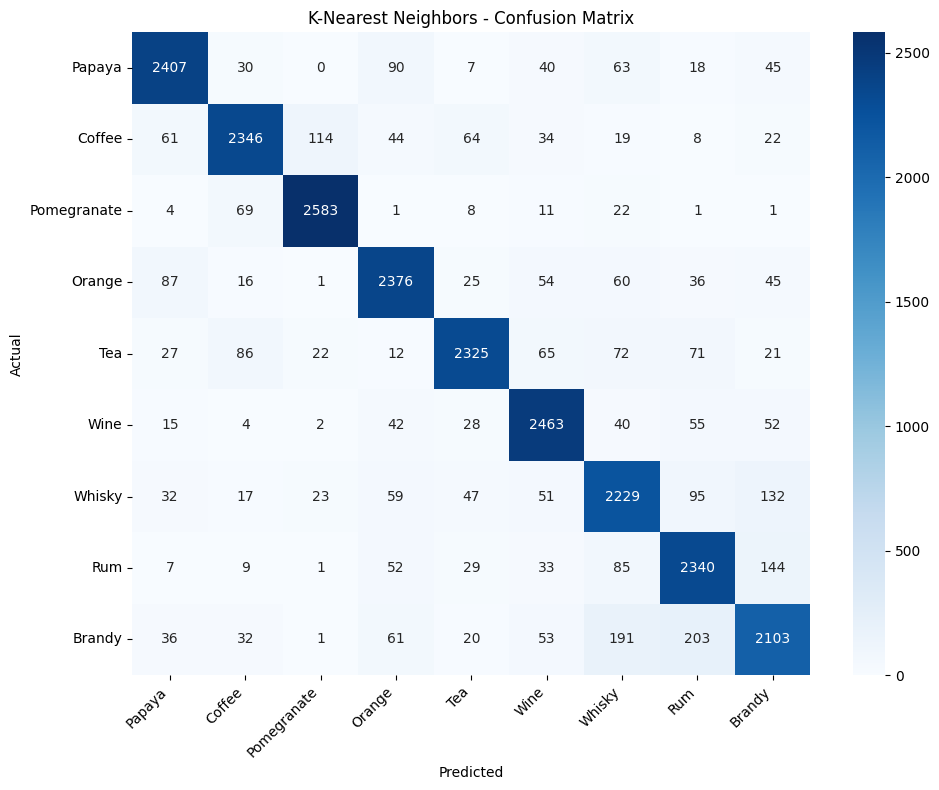

In [49]:
evaluate_model(
    model_name="K-Nearest Neighbors",
    model=knn_model,
    X_test=X_test_selected,
    y_test=y_test,
    training_time=training_time
)

## Step 14: Decision Tree

### Find the Optimal Maximum Depth for Decision Tree

In [50]:
depth_values = [5, 10, 15, 20, 25, 30, None]

dt_results = []

In [51]:
for depth in depth_values:

    print(f"\nTesting max_depth = {depth}")

    start_time = time.time()

    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(X_train_selected, y_train)

    train_time = time.time() - start_time

    y_pred = dt.predict(X_test_selected)

    accuracy = accuracy_score(y_test, y_pred)

    dt_results.append({
        "max_depth": depth,
        "Accuracy": accuracy,
        "Training Time (sec)": train_time
    })

    print(f"Accuracy = {accuracy:.4f}")


Testing max_depth = 5
Accuracy = 0.3966

Testing max_depth = 10
Accuracy = 0.6065

Testing max_depth = 15
Accuracy = 0.7506

Testing max_depth = 20
Accuracy = 0.7848

Testing max_depth = 25
Accuracy = 0.7911

Testing max_depth = 30
Accuracy = 0.7941

Testing max_depth = None
Accuracy = 0.7951


In [52]:
dt_results_df = pd.DataFrame(dt_results)

dt_results_df["Accuracy (%)"] = dt_results_df["Accuracy"] * 100

dt_results_df

,max_depth,Accuracy,Training Time (sec),Accuracy (%)
0,5.0,0.396601,16.958736,39.660068
1,10.0,0.606527,27.727973,60.652702
2,15.0,0.750566,40.037206,75.056587
3,20.0,0.784806,46.240834,78.480596
4,25.0,0.791103,48.713040,79.110251
5,30.0,0.794148,50.987549,79.414791
6,NaN,0.795094,50.199605,79.509445


In [53]:
dt_results_df.to_csv(
    "../reports/decision_tree_depth_search_results.csv",
    index=False
)

print("Decision Tree depth search results saved successfully!")

Decision Tree depth search results saved successfully!


In [54]:
start_time = time.time()

decision_tree_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

decision_tree_model.fit(
    X_train_selected,
    y_train
)

training_time = time.time() - start_time

Decision Tree Completed Successfully
Accuracy          : 79.51%
Precision (Macro) : 79.52%
Recall (Macro)    : 79.50%
F1 Score (Macro)  : 79.51%
Training Time     : 41.8591 sec
Prediction Time   : 0.0261 sec

Classification Report:

              precision    recall  f1-score   support

      Papaya     0.8119    0.8152    0.8135      2700
      Coffee     0.8192    0.8271    0.8231      2712
 Pomegranate     0.9225    0.9263    0.9244      2700
      Orange     0.8145    0.7870    0.8005      2700
         Tea     0.7849    0.7890    0.7869      2701
        Wine     0.7989    0.7986    0.7987      2701
      Whisky     0.7225    0.7214    0.7220      2685
         Rum     0.7715    0.7593    0.7654      2700
      Brandy     0.7112    0.7315    0.7212      2700

    accuracy                         0.7951     24299
   macro avg     0.7952    0.7950    0.7951     24299
weighted avg     0.7953    0.7951    0.7951     24299



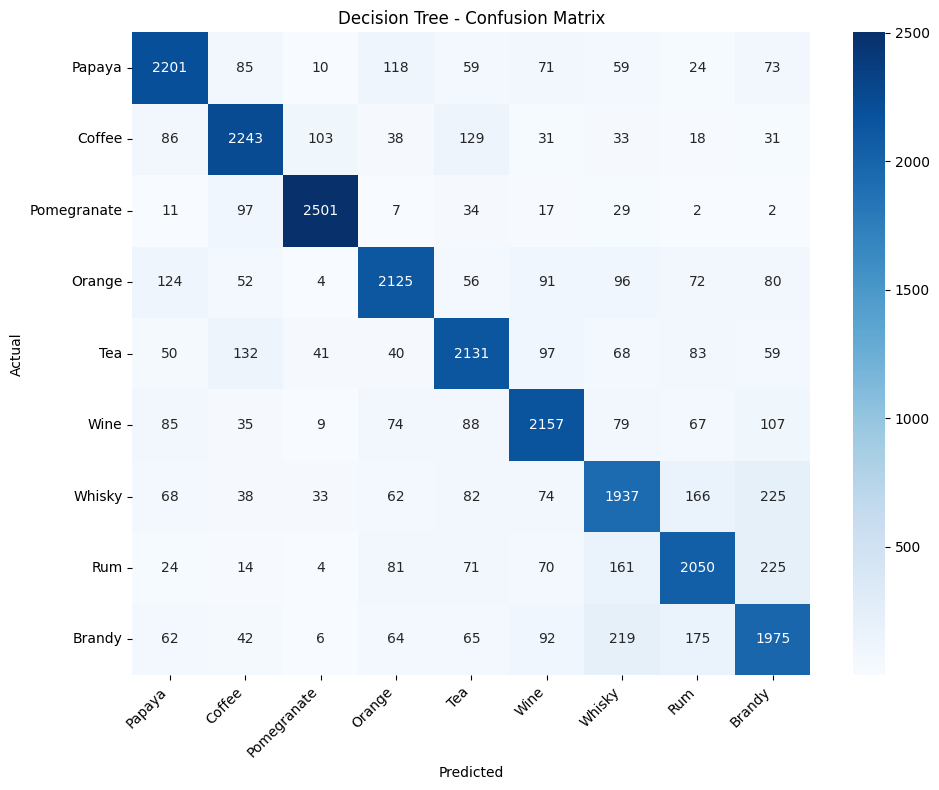

In [55]:
evaluate_model(
    model_name="Decision Tree",
    model=decision_tree_model,
    X_test=X_test_selected,
    y_test=y_test,
    training_time=training_time
)

## Step 15: Random Forest

###  Find the Optimal Number of Trees for Random Forest

In [56]:
n_estimators_values = [50, 100, 150, 200]

rf_results = []

In [64]:
for n in n_estimators_values:

    print(f"\nTesting n_estimators = {n}")

    start_time = time.time()

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_selected, y_train)

    train_time = time.time() - start_time

    y_pred = rf.predict(X_test_selected)

    accuracy = accuracy_score(y_test, y_pred)

    rf_results.append({
        "n_estimators": n,
        "Accuracy": accuracy,
        "Training Time (sec)": train_time
    })

    print(f"Accuracy = {accuracy:.4f}")


Testing n_estimators = 50
Accuracy = 0.8898

Testing n_estimators = 100
Accuracy = 0.8942

Testing n_estimators = 150
Accuracy = 0.8959

Testing n_estimators = 200
Accuracy = 0.8960


In [65]:
rf_results_df = pd.DataFrame(rf_results)

rf_results_df["Accuracy (%)"] = rf_results_df["Accuracy"] * 100

rf_results_df

,n_estimators,Accuracy,Training Time (sec),Accuracy (%)
0,50,0.889831,29.152066,88.983086
1,100,0.894152,72.092772,89.415202
2,150,0.895880,124.272793,89.588049
3,200,0.896004,162.109913,89.600395


In [67]:
rf_results_df.to_csv(
    "../reports/random_forest_n_estimators_search_results.csv",
    index=False
)

print("Random Forest search results saved successfully!")

Random Forest search results saved successfully!


In [57]:
start_time = time.time()

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_selected,
    y_train
)

training_time = time.time() - start_time

Random Forest Completed Successfully
Accuracy          : 89.60%
Precision (Macro) : 89.69%
Recall (Macro)    : 89.60%
F1 Score (Macro)  : 89.61%
Training Time     : 161.2592 sec
Prediction Time   : 0.5910 sec

Classification Report:

              precision    recall  f1-score   support

      Papaya     0.9295    0.9126    0.9209      2700
      Coffee     0.9411    0.8724    0.9055      2712
 Pomegranate     0.9609    0.9730    0.9669      2700
      Orange     0.9035    0.9259    0.9146      2700
         Tea     0.9166    0.8834    0.8997      2701
        Wine     0.9075    0.9082    0.9078      2701
      Whisky     0.8336    0.8380    0.8358      2685
         Rum     0.8370    0.8996    0.8672      2700
      Brandy     0.8426    0.8507    0.8467      2700

    accuracy                         0.8960     24299
   macro avg     0.8969    0.8960    0.8961     24299
weighted avg     0.8970    0.8960    0.8962     24299



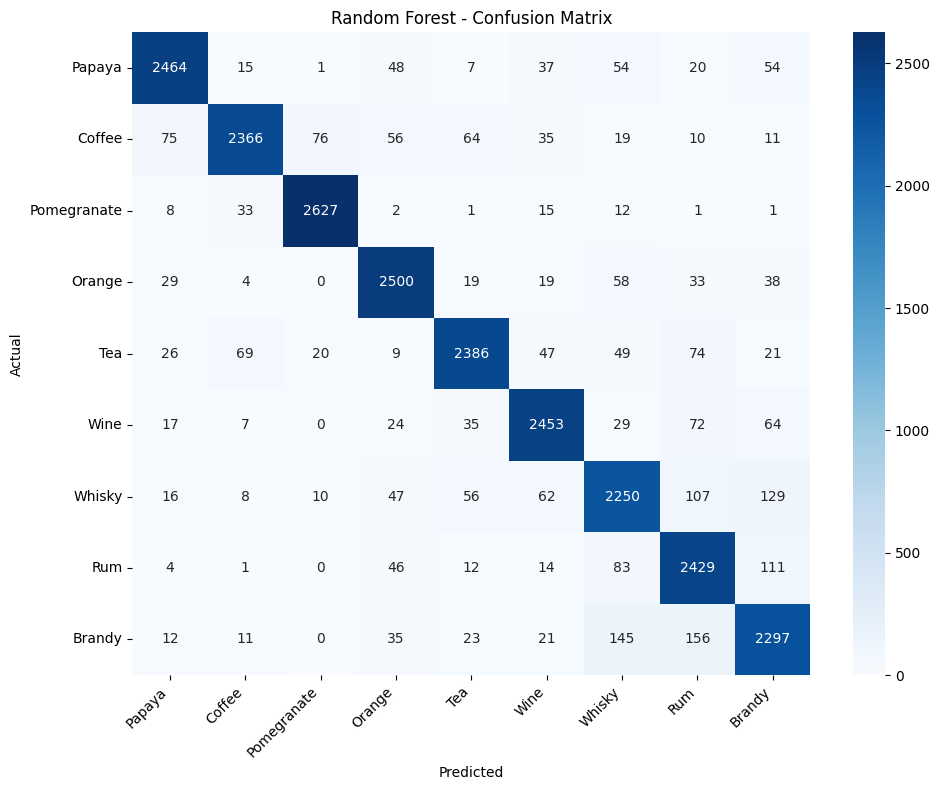

In [58]:
evaluate_model(
    model_name="Random Forest",
    model=random_forest_model,
    X_test=X_test_selected,
    y_test=y_test,
    training_time=training_time
)

## Step 16: Linear Support Vector Machine (SVM)

## Step 17: Naive Bayes

In [72]:
var_smoothing_values = [
    1e-12,
    1e-10,
    1e-9,
    1e-8,
    1e-7
]

nb_results = []

In [73]:
for v in var_smoothing_values:

    print(f"\nTesting var_smoothing = {v}")

    start_time = time.time()

    nb = GaussianNB(
        var_smoothing=v
    )

    nb.fit(
        X_train_selected,
        y_train
    )

    train_time = time.time() - start_time

    y_pred = nb.predict(X_test_selected)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    nb_results.append({
        "var_smoothing": v,
        "Accuracy": accuracy,
        "Training Time (sec)": train_time
    })

    print(f"Accuracy = {accuracy:.4f}")


Testing var_smoothing = 1e-12
Accuracy = 0.1940

Testing var_smoothing = 1e-10
Accuracy = 0.1940

Testing var_smoothing = 1e-09
Accuracy = 0.1940

Testing var_smoothing = 1e-08
Accuracy = 0.1940

Testing var_smoothing = 1e-07
Accuracy = 0.1940


In [74]:
nb_results_df = pd.DataFrame(nb_results)

nb_results_df["Accuracy (%)"] = (
    nb_results_df["Accuracy"] * 100
)

nb_results_df

,var_smoothing,Accuracy,Training Time (sec),Accuracy (%)
0,1.000000e-12,0.194,0.658539,19.399975
1,1.000000e-10,0.194,0.613232,19.399975
2,1.000000e-09,0.194,0.656583,19.399975
3,1.000000e-08,0.194,0.671856,19.399975
4,1.000000e-07,0.194,0.605218,19.399975


In [75]:
nb_results_df.to_csv(
    "../reports/naive_bayes_var_smoothing_search_results.csv",
    index=False
)

print("Naive Bayes search results saved successfully!")

Naive Bayes search results saved successfully!


In [59]:
start_time = time.time()

naive_bayes_model = GaussianNB(
    var_smoothing=1e-9
)

naive_bayes_model.fit(
    X_train_selected,
    y_train
)

training_time = time.time() - start_time

Naive Bayes Completed Successfully
Accuracy          : 19.40%
Precision (Macro) : 7.36%
Recall (Macro)    : 19.40%
F1 Score (Macro)  : 10.04%
Training Time     : 0.5484 sec
Prediction Time   : 0.5395 sec

Classification Report:

              precision    recall  f1-score   support

      Papaya     0.0000    0.0000    0.0000      2700
      Coffee     0.0000    0.0000    0.0000      2712
 Pomegranate     0.2683    0.6419    0.3784      2700
      Orange     0.1481    0.4874    0.2272      2700
         Tea     0.0000    0.0000    0.0000      2701
        Wine     0.0000    0.0000    0.0000      2701
      Whisky     0.0000    0.0000    0.0000      2685
         Rum     0.0560    0.0048    0.0089      2700
      Brandy     0.1896    0.6119    0.2895      2700

    accuracy                         0.1940     24299
   macro avg     0.0736    0.1940    0.1004     24299
weighted avg     0.0736    0.1940    0.1004     24299



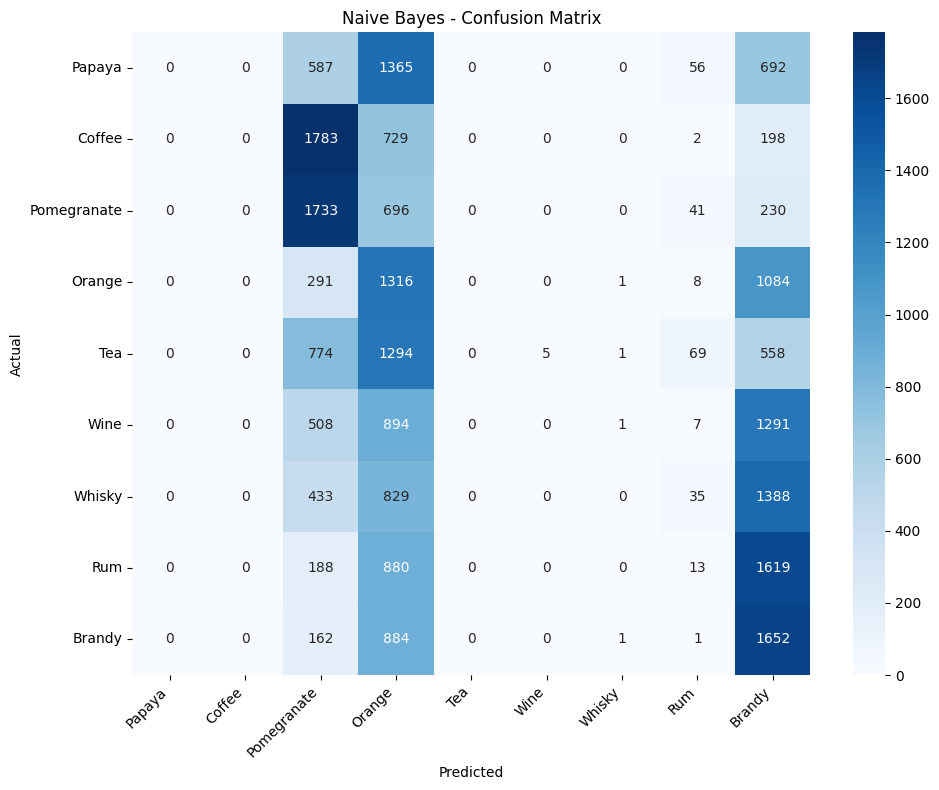

In [60]:
evaluate_model(
    model_name="Naive Bayes",
    model=naive_bayes_model,
    X_test=X_test_selected,
    y_test=y_test,
    training_time=training_time
)

## Step 18: Gradient Boosting

### hyperparameter search for no. of boosting trees.

In [84]:
gb_estimators = [50, 100, 150, 200]

gb_results = []

In [85]:
for n in gb_estimators:

    print(f"\nTesting n_estimators = {n}")

    start_time = time.time()

    gb = GradientBoostingClassifier(
        n_estimators=n,
        random_state=42
    )

    gb.fit(
        X_train_selected,
        y_train
    )

    train_time = time.time() - start_time

    y_pred = gb.predict(X_test_selected)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    gb_results.append({
        "n_estimators": n,
        "Accuracy": accuracy,
        "Training Time (sec)": train_time
    })

    print(f"Accuracy = {accuracy:.4f}")


Testing n_estimators = 50
Accuracy = 0.6436

Testing n_estimators = 100
Accuracy = 0.7104

Testing n_estimators = 150
Accuracy = 0.7493

Testing n_estimators = 200
Accuracy = 0.7768


In [86]:
gb_results_df = pd.DataFrame(gb_results)

gb_results_df["Accuracy (%)"] = (
    gb_results_df["Accuracy"] * 100
)

gb_results_df

,n_estimators,Accuracy,Training Time (sec),Accuracy (%)
0,50,0.643648,3368.070447,64.364789
1,100,0.710358,6569.879243,71.035845
2,150,0.749290,12645.962337,74.929009
3,200,0.776781,13070.672250,77.678094


In [87]:
gb_results_df.to_csv(
    "../reports/gradient_boosting_n_estimators_search_results.csv",
    index=False
)

print("Gradient Boosting search results saved successfully!")

Gradient Boosting search results saved successfully!


In [61]:
start_time = time.time()

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)

gradient_boosting_model.fit(
    X_train_selected,
    y_train
)

training_time = time.time() - start_time

Gradient Boosting Completed Successfully
Accuracy          : 77.68%
Precision (Macro) : 78.38%
Recall (Macro)    : 77.67%
F1 Score (Macro)  : 77.83%
Training Time     : 13746.5939 sec
Prediction Time   : 4.1872 sec

Classification Report:

              precision    recall  f1-score   support

      Papaya     0.8601    0.8222    0.8407      2700
      Coffee     0.8800    0.7920    0.8337      2712
 Pomegranate     0.9217    0.9415    0.9315      2700
      Orange     0.8503    0.7741    0.8104      2700
         Tea     0.8268    0.6997    0.7580      2701
        Wine     0.6670    0.7904    0.7235      2701
      Whisky     0.6754    0.6842    0.6797      2685
         Rum     0.7245    0.7637    0.7436      2700
      Brandy     0.6486    0.7226    0.6836      2700

    accuracy                         0.7768     24299
   macro avg     0.7838    0.7767    0.7783     24299
weighted avg     0.7839    0.7768    0.7784     24299



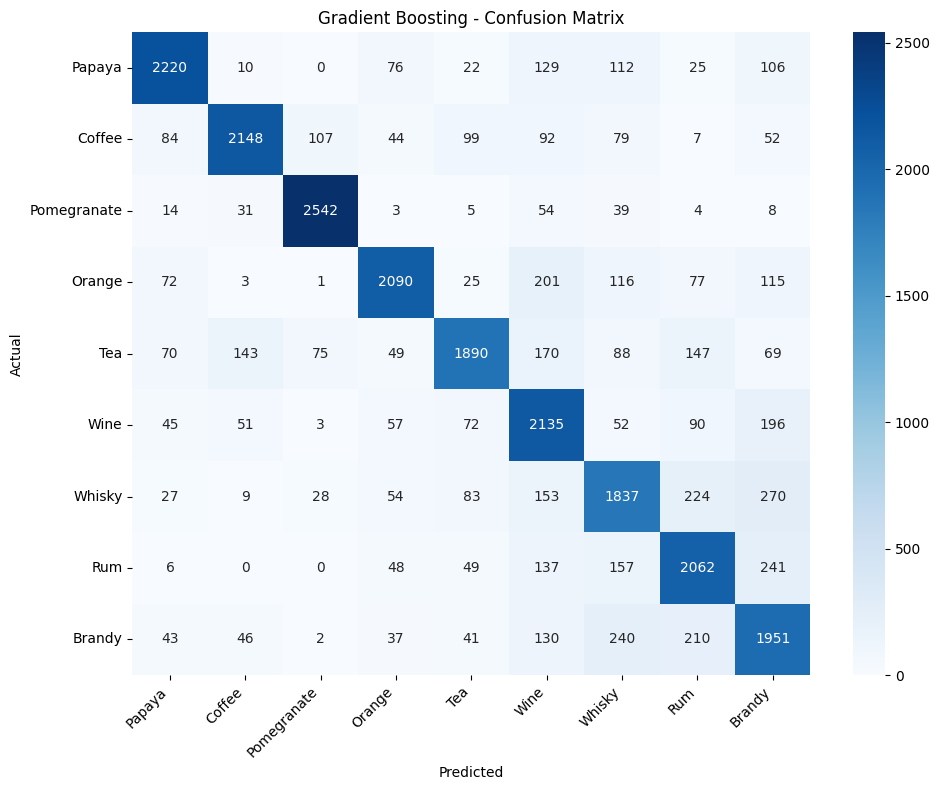

In [62]:
evaluate_model(
    model_name="Gradient Boosting",
    model=gradient_boosting_model,
    X_test=X_test_selected,
    y_test=y_test,
    training_time=training_time
)

In [55]:
c_values = [0.1, 1, 10, 100]

svm_results = []

for c in c_values:

    print(f"Testing C = {c}")

    start_time = time.time()

    svm = LinearSVC(
        C=c,
        random_state=42,
        max_iter=10000
    )

    svm.fit(X_train_selected, y_train)

    train_time = time.time() - start_time

    y_pred = svm.predict(X_test_selected)

    accuracy = accuracy_score(y_test, y_pred)

    svm_results.append({
        "C": c,
        "Accuracy": accuracy,
        "Training_Time": train_time
    })

svm_results_df = pd.DataFrame(svm_results)

display(svm_results_df)

Testing C = 0.1
Testing C = 1
Testing C = 10
Testing C = 100


D:\Hyperspectral_Beverage_Classification\venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,C,Accuracy,Training_Time
0,0.1,0.652002,134.941480
1,1.0,0.671880,846.930874
2,10.0,0.674925,1128.705085
3,100.0,0.668299,2174.492705


In [60]:
svm_results_df.to_csv(
    "../reports/svm_c_search_results.csv",
    index=False
)

print("SVM C search results saved successfully!")

SVM C search results saved successfully!


In [ ]:
start_time = time.time()

svm_model = LinearSVC(
    C=10,
    random_state=42,
    max_iter=10000
)

svm_model.fit(X_train_selected, y_train)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.4f} seconds")

In [ ]:
start_prediction = time.time()

y_pred = svm_model.predict(X_test_selected)

prediction_time = time.time() - start_prediction

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("Linear SVM Completed Successfully")
print("=" * 70)

print(f"Accuracy          : {accuracy*100:.2f}%")
print(f"Precision (Macro) : {precision*100:.2f}%")
print(f"Recall (Macro)    : {recall*100:.2f}%")
print(f"F1 Score (Macro)  : {f1*100:.2f}%")
print(f"Training Time     : {training_time:.4f} sec")
print(f"Prediction Time   : {prediction_time:.4f} sec")

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Linear SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Deep Learning Models

In [41]:
print("Minimum label:", y_train.min())
print("Maximum label:", y_train.max())

print("Unique labels:")
print(sorted(y_train.unique()))

Minimum label: 1
Maximum label: 9
Unique labels:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [42]:
y_train_dl = y_train - 1
y_test_dl = y_test - 1

print("Minimum label:", y_train_dl.min())
print("Maximum label:", y_train_dl.max())
print(sorted(y_train_dl.unique()))

Minimum label: 0
Maximum label: 8
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [43]:
y_train_dl = to_categorical(y_train_dl, num_classes=9)
y_test_dl = to_categorical(y_test_dl, num_classes=9)

print("Training labels shape:", y_train_dl.shape)
print("Testing labels shape :", y_test_dl.shape)

Training labels shape: (97196, 9)
Testing labels shape : (24299, 9)


## Step 19: Multi-Layer Perceptron (MLP)

In [44]:
mlp_model = Sequential([

    Input(shape=(X_train_selected.shape[1],)),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(9, activation="softmax")
])

mlp_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │          52,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 9)                   │             585 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 94,217 (368.04 KB)

 Trainable params: 94,217 (368.04 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
mlp_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("MLP Model Compiled Successfully!")

MLP Model Compiled Successfully!


In [46]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [47]:
start_time = time.time()

history = mlp_model.fit(
    X_train_selected,
    y_train_dl,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")

Epoch 1/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5318 - loss: 1.3233 - val_accuracy: 0.6681 - val_loss: 1.0095
Epoch 2/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6398 - loss: 1.0829 - val_accuracy: 0.7048 - val_loss: 0.8800
Epoch 3/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6772 - loss: 0.9192 - val_accuracy: 0.7531 - val_loss: 0.8454
Epoch 4/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6950 - loss: 0.8403 - val_accuracy: 0.7758 - val_loss: 0.7212
Epoch 5/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7158 - loss: 0.7991 - val_accuracy: 0.7899 - val_loss: 0.7324
Epoch 6/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7268 - loss: 0.7890 - val_accuracy: 0.7998 - val_loss: 0.6781
Epoch 7/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7413 - loss: 0.7387 - val_accuracy: 0.7970 - val_loss: 0.6262
Epoch 8/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7407 - l

760/760 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
MLP Completed Successfully
Accuracy          : 92.03%
Precision (Macro) : 92.13%
Recall (Macro)    : 92.04%
F1 Score (Macro)  : 91.97%
Training Time     : 1124.1771 sec
Prediction Time   : 1.0672 sec

Classification Report:

              precision    recall  f1-score   support

      Papaya     0.9600    0.9600    0.9600      2700
      Coffee     0.9309    0.7795    0.8485      2712
 Pomegranate     0.8885    0.9537    0.9200      2700
      Orange     0.9436    0.9537    0.9486      2700
         Tea     0.9020    0.9271    0.9144      2701
        Wine     0.9705    0.9630    0.9667      2701
      Whisky     0.8659    0.9426    0.9026      2685
         Rum     0.9145    0.9185    0.9165      2700
      Brandy     0.9157    0.8852    0.9002      2700

    accuracy                         0.9203     24299
   macro avg     0.9213    0.9204    0.9197     24299
weighted avg     0.9213    0.9203    0.9197     24299



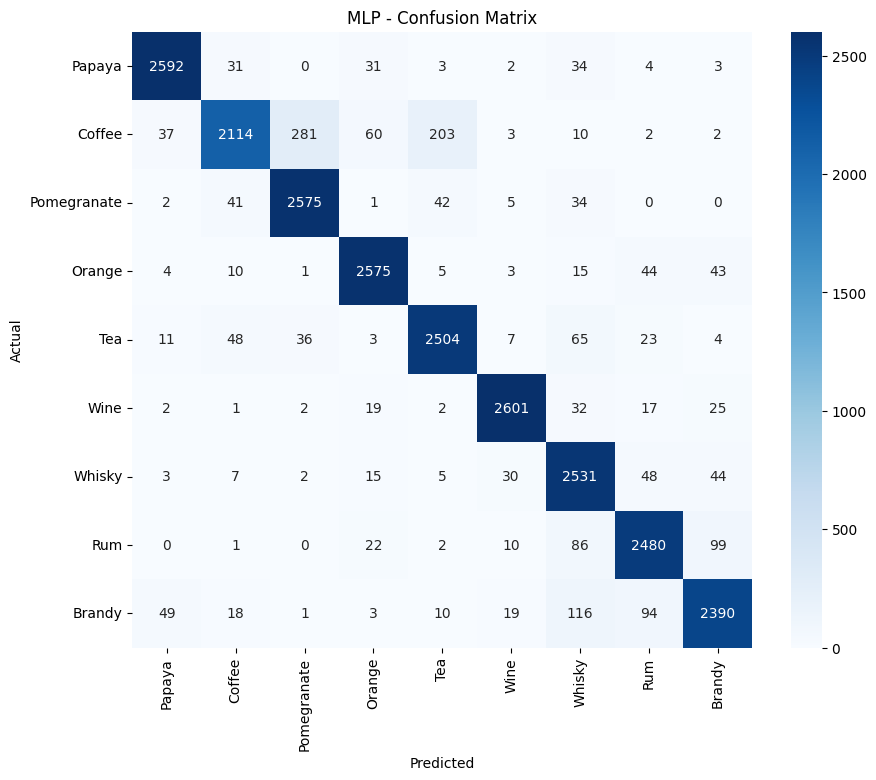

In [48]:
start_prediction = time.time()

y_pred_prob = mlp_model.predict(X_test_selected)

prediction_time = time.time() - start_prediction

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_dl, axis=1)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print("="*70)
print("MLP Completed Successfully")
print("="*70)

print(f"Accuracy          : {accuracy*100:.2f}%")
print(f"Precision (Macro) : {precision*100:.2f}%")
print(f"Recall (Macro)    : {recall*100:.2f}%")
print(f"F1 Score (Macro)  : {f1*100:.2f}%")
print(f"Training Time     : {training_time:.4f} sec")
print(f"Prediction Time   : {prediction_time:.4f} sec")

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("MLP - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "../reports/mlp_training_history.csv",
    index=False
)

print("MLP training history saved successfully!")

MLP training history saved successfully!


In [50]:
import os

os.makedirs("../models", exist_ok=True)

mlp_model.save("../models/mlp_model.keras")

print("✅ MLP model saved successfully!")

✅ MLP model saved successfully!


In [52]:
import os

print(os.listdir("../models"))

['mlp_model.keras']


## Step 20: 1D Convolutional Neural Network (1D CNN)

In [46]:
# Reshape data for 1D CNN

X_train_cnn = X_train_selected.reshape(
    X_train_selected.shape[0],
    X_train_selected.shape[1],
    1
)

X_test_cnn = X_test_selected.reshape(
    X_test_selected.shape[0],
    X_test_selected.shape[1],
    1
)

print("Training shape :", X_train_cnn.shape)
print("Testing shape  :", X_test_cnn.shape)

Training shape : (97196, 204, 1)
Testing shape  : (24299, 204, 1)


In [81]:
# Build 1D CNN Model

cnn_model = Sequential([

    Input(shape=(204, 1)),

    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu"
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu"
    ),

    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.3),

    Dense(9, activation="softmax")
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 202, 32)             │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 101, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 99, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 49, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 409,033 (1.56 MB)

 Trainable params: 409,033 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

In [82]:
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN Model Compiled Successfully!")

CNN Model Compiled Successfully!


In [83]:
# Train CNN Model

start_time = time.time()

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_dl,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")

Epoch 1/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.5308 - loss: 1.3908 - val_accuracy: 0.6383 - val_loss: 1.1051
Epoch 2/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.6206 - loss: 1.1194 - val_accuracy: 0.6807 - val_loss: 0.9539
Epoch 3/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.6585 - loss: 1.0027 - val_accuracy: 0.7229 - val_loss: 0.8118
Epoch 4/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.6909 - loss: 0.8858 - val_accuracy: 0.7372 - val_loss: 0.7317
Epoch 5/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 38s 16ms/step - accuracy: 0.7181 - loss: 0.7838 - val_accuracy: 0.7608 - val_loss: 0.6711
Epoch 6/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.7404 - loss: 0.7089 - val_accuracy: 0.7931 - val_loss: 0.5931
Epoch 7/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.7583 - loss: 0.6642 - val_accuracy: 0.8129 - val_loss: 0.5261
Epoch 8/100
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 

760/760 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step
1D CNN Completed Successfully
Accuracy          : 62.96%
Precision (Macro) : 64.14%
Recall (Macro)    : 62.95%
F1 Score (Macro)  : 62.56%
Training Time     : 368.1343 sec
Prediction Time   : 10.5583 sec

Classification Report:

              precision    recall  f1-score   support

      Papaya     0.8502    0.7800    0.8136      2700
      Coffee     0.8302    0.5608    0.6695      2712
 Pomegranate     0.6466    0.9493    0.7692      2700
      Orange     0.7130    0.6956    0.7042      2700
         Tea     0.6850    0.4832    0.5667      2701
        Wine     0.5662    0.6857    0.6202      2701
      Whisky     0.4610    0.3922    0.4238      2685
         Rum     0.5021    0.6241    0.5565      2700
      Brandy     0.5186    0.4948    0.5064      2700

    accuracy                         0.6296     24299
   macro avg     0.6414    0.6295    0.6256     24299
weighted avg     0.6416    0.6296    0.6257     24299



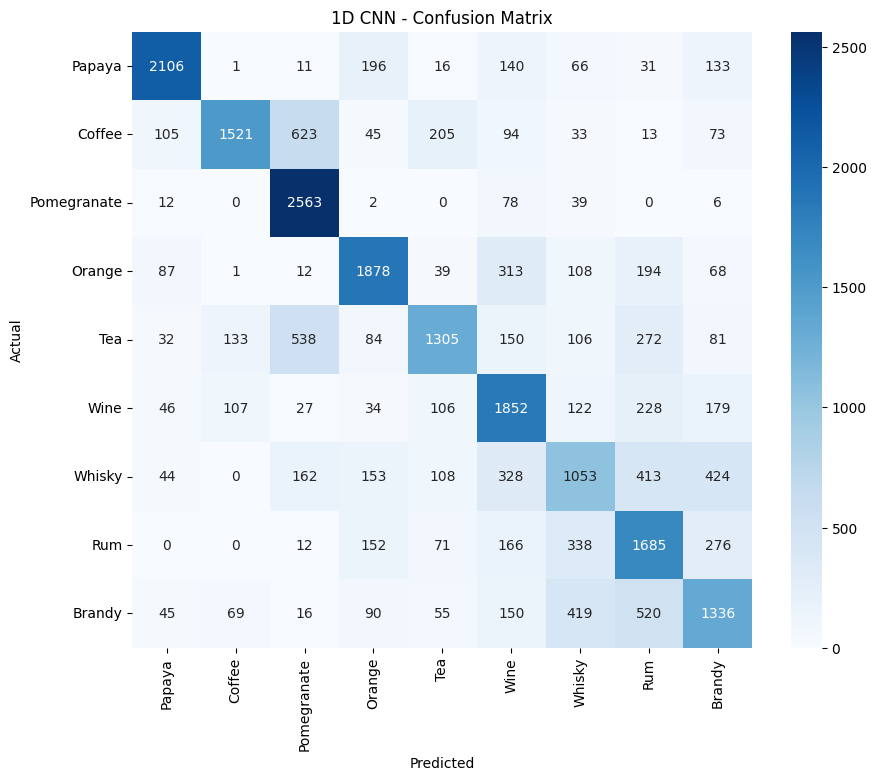

In [84]:
# Evaluate CNN Model

start_prediction = time.time()

y_pred_prob = cnn_model.predict(X_test_cnn)

prediction_time = time.time() - start_prediction

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_dl, axis=1)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("1D CNN Completed Successfully")
print("=" * 70)

print(f"Accuracy          : {accuracy*100:.2f}%")
print(f"Precision (Macro) : {precision*100:.2f}%")
print(f"Recall (Macro)    : {recall*100:.2f}%")
print(f"F1 Score (Macro)  : {f1*100:.2f}%")
print(f"Training Time     : {training_time:.4f} sec")
print(f"Prediction Time   : {prediction_time:.4f} sec")

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("1D CNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [85]:
history_df = pd.DataFrame(cnn_history.history)

history_df.to_csv(
    "../reports/cnn_training_history.csv",
    index=False
)

print("CNN training history saved successfully!")

CNN training history saved successfully!


## Step 21: Long Short-Term Memory (LSTM)

In [86]:
lstm_model = Sequential([

    Input(shape=(204, 1)),

    LSTM(128),

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(9, activation="softmax")
])

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 128)                 │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 9)                   │             585 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 75,401 (294.54 KB)

 Trainable params: 75,401 (294.54 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("LSTM Model Compiled Successfully!")

LSTM Model Compiled Successfully!


In [92]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_cnn,
    y_train_dl,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[lstm_early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")

Epoch 1/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 406s 167ms/step - accuracy: 0.2260 - loss: 2.0057 - val_accuracy: 0.2715 - val_loss: 1.9402
Epoch 2/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 370s 152ms/step - accuracy: 0.2814 - loss: 1.8575 - val_accuracy: 0.3478 - val_loss: 1.7055
Epoch 3/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 382s 157ms/step - accuracy: 0.3360 - loss: 1.7221 - val_accuracy: 0.3754 - val_loss: 1.6260
Epoch 4/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 377s 155ms/step - accuracy: 0.3762 - loss: 1.6194 - val_accuracy: 0.4084 - val_loss: 1.5277
Epoch 5/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 432s 178ms/step - accuracy: 0.3638 - loss: 1.6416 - val_accuracy: 0.4130 - val_loss: 1.4907
Epoch 6/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 374s 154ms/step - accuracy: 0.2463 - loss: 1.9384 - val_accuracy: 0.2265 - val_loss: 2.0072
Epoch 7/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 486s 200ms/step - accuracy: 0.2327 - loss: 1.9711 - val_accuracy: 0.2753 - val_loss: 1.8264
Epoch 8/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 469s 193ms/step - ac

In [90]:
lstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

760/760 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step
LSTM Completed Successfully
Accuracy          : 40.89%
Precision (Macro) : 43.19%
Recall (Macro)    : 40.87%
F1 Score (Macro)  : 39.29%
Training Time     : 8195.5962 sec
Prediction Time   : 82.3372 sec

Classification Report:

              precision    recall  f1-score   support

      Papaya     0.4627    0.3885    0.4224      2700
      Coffee     0.8248    0.5538    0.6627      2712
 Pomegranate     0.6322    0.7733    0.6957      2700
      Orange     0.3132    0.6200    0.4162      2700
         Tea     0.3178    0.2529    0.2816      2701
        Wine     0.3784    0.1037    0.1627      2701
      Whisky     0.3079    0.1777    0.2253      2685
         Rum     0.2878    0.5715    0.3828      2700
      Brandy     0.3620    0.2367    0.2862      2700

    accuracy                         0.4089     24299
   macro avg     0.4319    0.4087    0.3929     24299
weighted avg     0.4321    0.4089    0.3931     24299



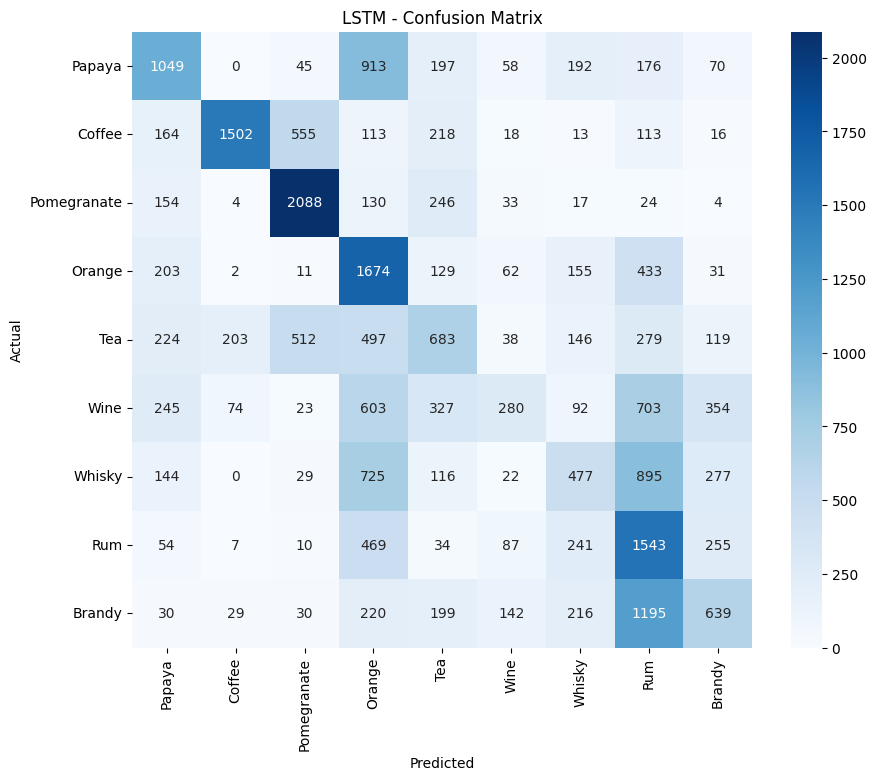

In [93]:
start_prediction = time.time()

y_pred_prob = lstm_model.predict(X_test_cnn)

prediction_time = time.time() - start_prediction

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_dl, axis=1)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("LSTM Completed Successfully")
print("=" * 70)

print(f"Accuracy          : {accuracy*100:.2f}%")
print(f"Precision (Macro) : {precision*100:.2f}%")
print(f"Recall (Macro)    : {recall*100:.2f}%")
print(f"F1 Score (Macro)  : {f1*100:.2f}%")
print(f"Training Time     : {training_time:.4f} sec")
print(f"Prediction Time   : {prediction_time:.4f} sec")

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("LSTM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [97]:
history_df = pd.DataFrame(lstm_history.history)

history_df.to_csv(
    "../reports/lstm_training_history.csv",
    index=False
)

print("LSTM training history saved successfully!")

LSTM training history saved successfully!


## Step 22: CNN-LSTM

In [47]:
cnn_lstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [48]:
cnn_lstm_model = Sequential([

    Input(shape=(204, 1)),

    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu"
    ),

    MaxPooling1D(pool_size=2),

    LSTM(64),

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(9, activation="softmax")
])

cnn_lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 202, 32)             │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 101, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 9)                   │             585 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,705 (116.04 KB)

 Trainable params: 29,705 (116.04 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
cnn_lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN-LSTM Model Compiled Successfully!")

CNN-LSTM Model Compiled Successfully!


In [50]:
start_time = time.time()

cnn_lstm_history = cnn_lstm_model.fit(
    X_train_cnn,
    y_train_dl,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[cnn_lstm_early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")

Epoch 1/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 101s 41ms/step - accuracy: 0.2956 - loss: 1.7989 - val_accuracy: 0.3931 - val_loss: 1.5618
Epoch 2/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 135s 56ms/step - accuracy: 0.4124 - loss: 1.5144 - val_accuracy: 0.4916 - val_loss: 1.3397
Epoch 3/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 117s 48ms/step - accuracy: 0.4647 - loss: 1.3944 - val_accuracy: 0.5170 - val_loss: 1.2606
Epoch 4/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 170s 70ms/step - accuracy: 0.5102 - loss: 1.2876 - val_accuracy: 0.5669 - val_loss: 1.1607
Epoch 5/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 121s 50ms/step - accuracy: 0.5444 - loss: 1.1922 - val_accuracy: 0.5580 - val_loss: 1.1733
Epoch 6/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 106s 44ms/step - accuracy: 0.5840 - loss: 1.1015 - val_accuracy: 0.6448 - val_loss: 0.9579
Epoch 7/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 107s 44ms/step - accuracy: 0.5840 - loss: 1.1271 - val_accuracy: 0.6462 - val_loss: 0.9378
Epoch 8/50
2430/2430 ━━━━━━━━━━━━━━━━━━━━ 95s 39ms/step - accuracy: 0

760/760 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step
CNN-LSTM Completed Successfully
Accuracy          : 83.83%
Precision (Macro) : 84.15%
Recall (Macro)    : 83.83%
F1 Score (Macro)  : 83.77%
Training Time     : 5387.0082 sec
Prediction Time   : 10.1044 sec

Classification Report:

              precision    recall  f1-score   support

      Papaya     0.9065    0.8907    0.8986      2700
      Coffee     0.9282    0.7341    0.8198      2712
 Pomegranate     0.8598    0.9741    0.9134      2700
      Orange     0.8685    0.8930    0.8806      2700
         Tea     0.8624    0.7867    0.8228      2701
        Wine     0.8644    0.9178    0.8903      2701
      Whisky     0.7554    0.7717    0.7634      2685
         Rum     0.8072    0.7770    0.7918      2700
      Brandy     0.7213    0.7993    0.7583      2700

    accuracy                         0.8383     24299
   macro avg     0.8415    0.8383    0.8377     24299
weighted avg     0.8416    0.8383    0.8377     24299



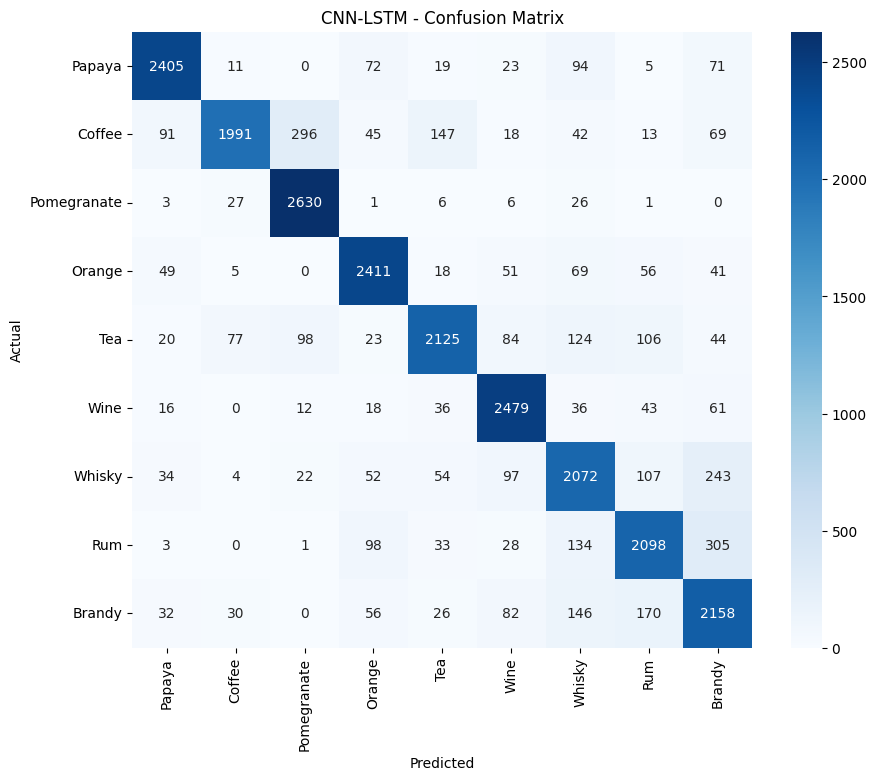

In [51]:
start_prediction = time.time()

y_pred_prob = cnn_lstm_model.predict(X_test_cnn)

prediction_time = time.time() - start_prediction

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_dl, axis=1)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("CNN-LSTM Completed Successfully")
print("=" * 70)

print(f"Accuracy          : {accuracy*100:.2f}%")
print(f"Precision (Macro) : {precision*100:.2f}%")
print(f"Recall (Macro)    : {recall*100:.2f}%")
print(f"F1 Score (Macro)  : {f1*100:.2f}%")
print(f"Training Time     : {training_time:.4f} sec")
print(f"Prediction Time   : {prediction_time:.4f} sec")

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN-LSTM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Step 23: Final Model Comparison

In [62]:
comparison_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes",
        "Linear SVM",
        "Gradient Boosting",
        "MLP",
        "1D CNN",
        "LSTM",
        "CNN-LSTM"
    ],

    "Accuracy (%)": [
        65.89,
        87.13,
        79.51,
        89.60,
        19.40,
        67.49,
        77.68,
        92.12,
        62.96,
        40.89,
        83.83
    ],

    "Precision (%)": [
        66.23,
        87.17,
        79.52,
        89.69,
        7.36,
        67.28,
        78.38,
        92.17,
        64.14,
        43.19,
        84.15
    ],

    "Recall (%)": [
        65.87,
        87.13,
        79.50,
        89.60,
        19.40,
        67.47,
        77.67,
        92.12,
        62.95,
        40.87,
        83.83
    ],

    "F1 Score (%)": [
        65.52,
        87.12,
        79.51,
        89.61,
        10.04,
        66.53,
        77.83,
        92.08,
        62.56,
        39.29,
        83.77
    ],

    "Training Time (sec)": [
        657.4583,
        0.1501,
        41.8591,
        161.2592,
        0.5484,
        1223.1991,
        13746.5939,
        747.2836,
        368.1343,
        8195.5962,
        5387.0082
    ],

    "Prediction Time (sec)": [
        0.0410,
        23.2961,
        0.0261,
        0.5910,
        0.5395,
        0.0296,
        0.2688,
        1.0445,
        10.5570,
        82.3387,
        10.1044
    ]
})

comparison_results

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),Training Time (sec),Prediction Time (sec)
0,Logistic Regression,65.89,66.23,65.87,65.52,657.4583,0.0410
1,KNN,87.13,87.17,87.13,87.12,0.1501,23.2961
2,Decision Tree,79.51,79.52,79.50,79.51,41.8591,0.0261
3,Random Forest,89.60,89.69,89.60,89.61,161.2592,0.5910
4,Naive Bayes,19.40,7.36,19.40,10.04,0.5484,0.5395
5,Linear SVM,67.49,67.28,67.47,66.53,1223.1991,0.0296
6,Gradient Boosting,77.68,78.38,77.67,77.83,13746.5939,0.2688
7,MLP,92.12,92.17,92.12,92.08,747.2836,1.0445
8,1D CNN,62.96,64.14,62.95,62.56,368.1343,10.5570
9,LSTM,40.89,43.19,40.87,39.29,8195.5962,82.3387


In [63]:
comparison_results.to_csv(
    "../reports/final_model_comparison.csv",
    index=False
)

print("Final comparison table saved successfully!")

Final comparison table saved successfully!


## Graphs


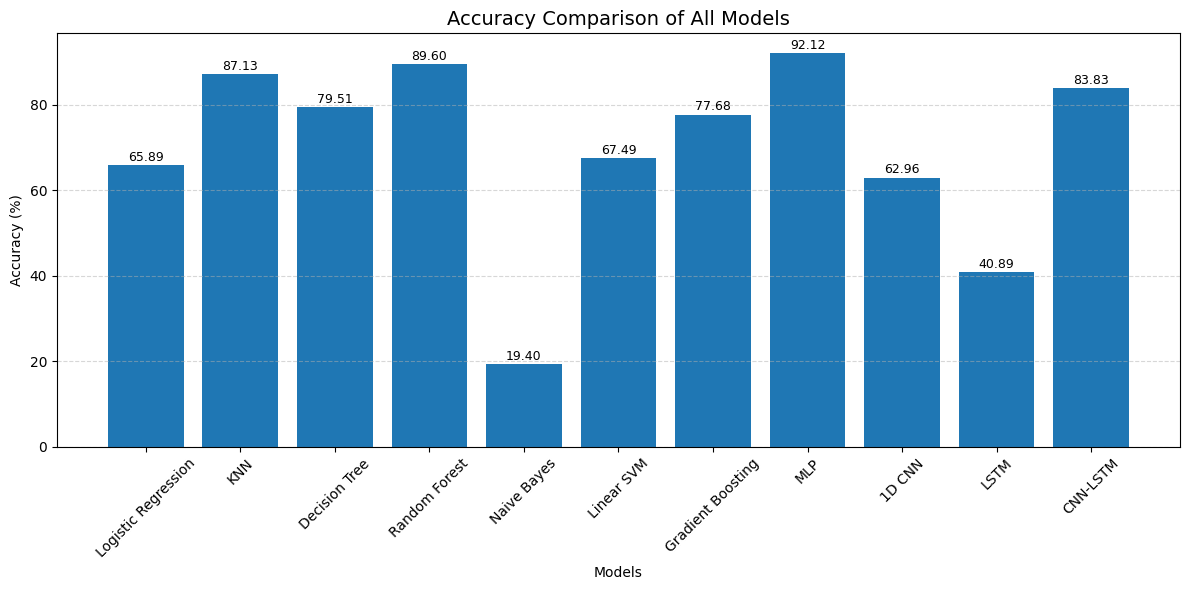

In [65]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    comparison_results["Model"],
    comparison_results["Accuracy (%)"]
)

plt.title("Accuracy Comparison of All Models", fontsize=14)

plt.xlabel("Models")

plt.ylabel("Accuracy (%)")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

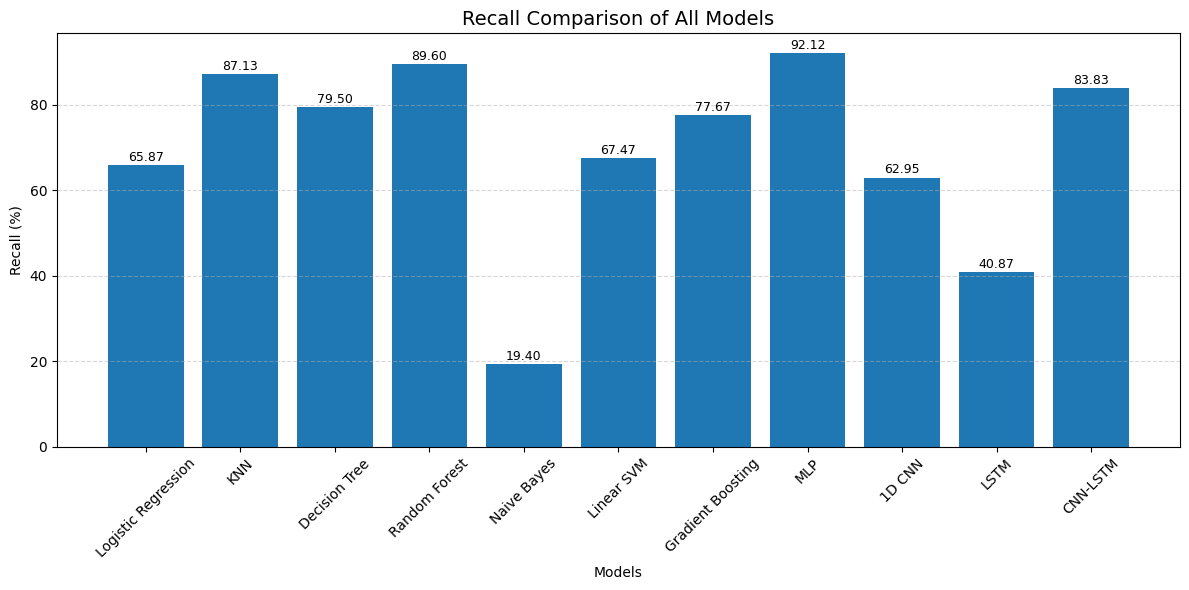

In [67]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    comparison_results["Model"],
    comparison_results["Recall (%)"]
)

plt.title("Recall Comparison of All Models", fontsize=14)

plt.xlabel("Models")
plt.ylabel("Recall (%)")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

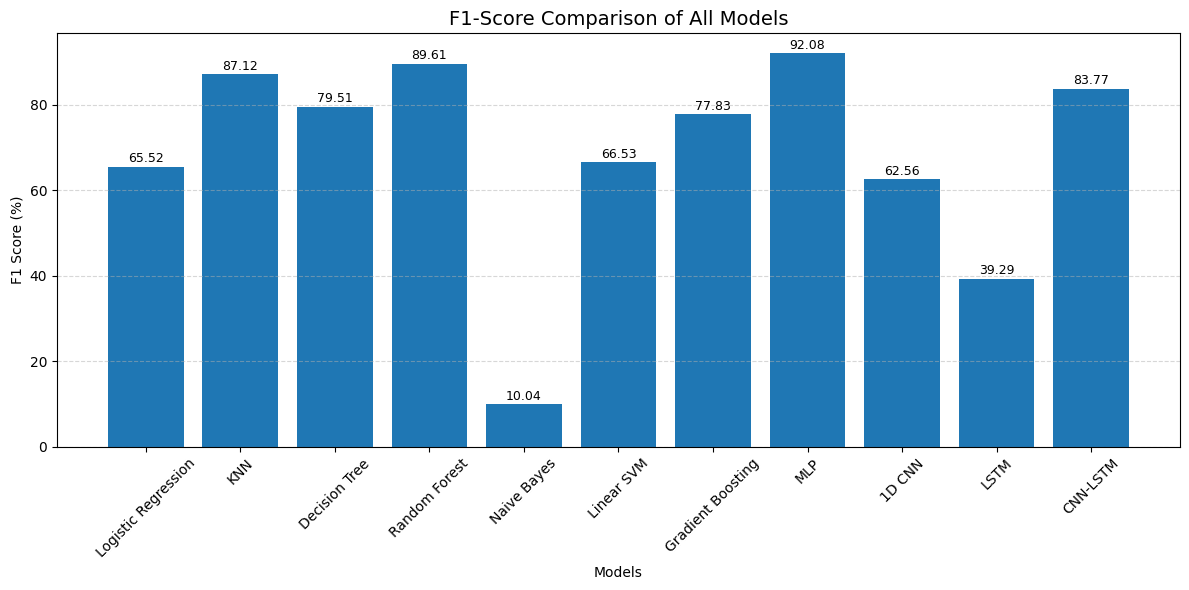

In [68]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    comparison_results["Model"],
    comparison_results["F1 Score (%)"]
)

plt.title("F1-Score Comparison of All Models", fontsize=14)

plt.xlabel("Models")
plt.ylabel("F1 Score (%)")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

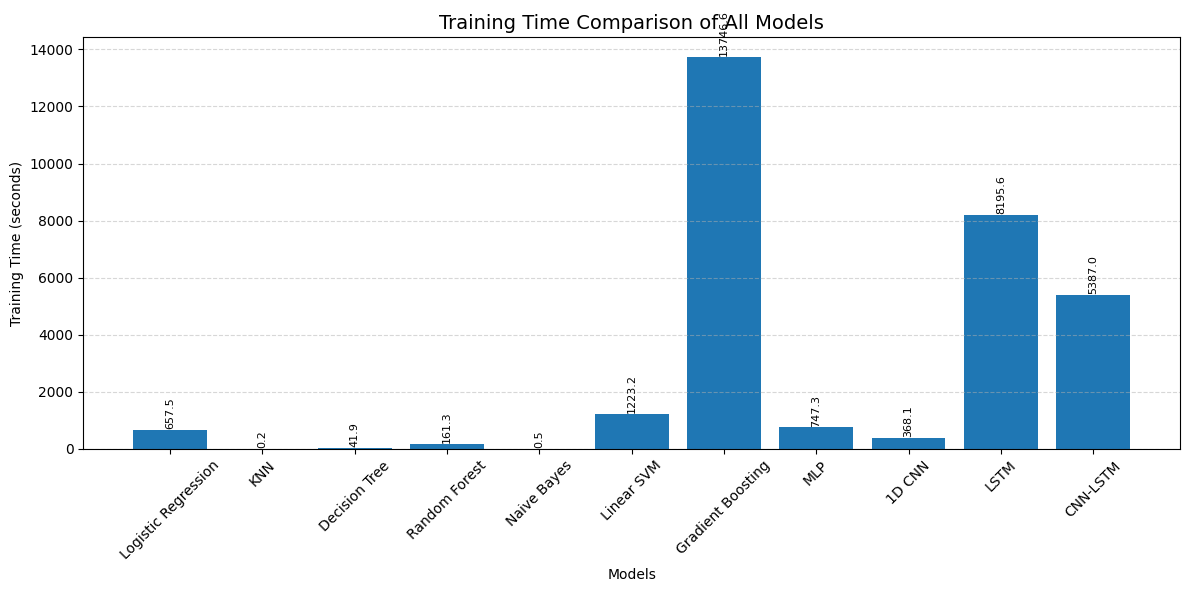

In [69]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    comparison_results["Model"],
    comparison_results["Training Time (sec)"]
)

plt.title("Training Time Comparison of All Models", fontsize=14)

plt.xlabel("Models")
plt.ylabel("Training Time (seconds)")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 100,
        f"{height:.1f}",
        ha="center",
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()

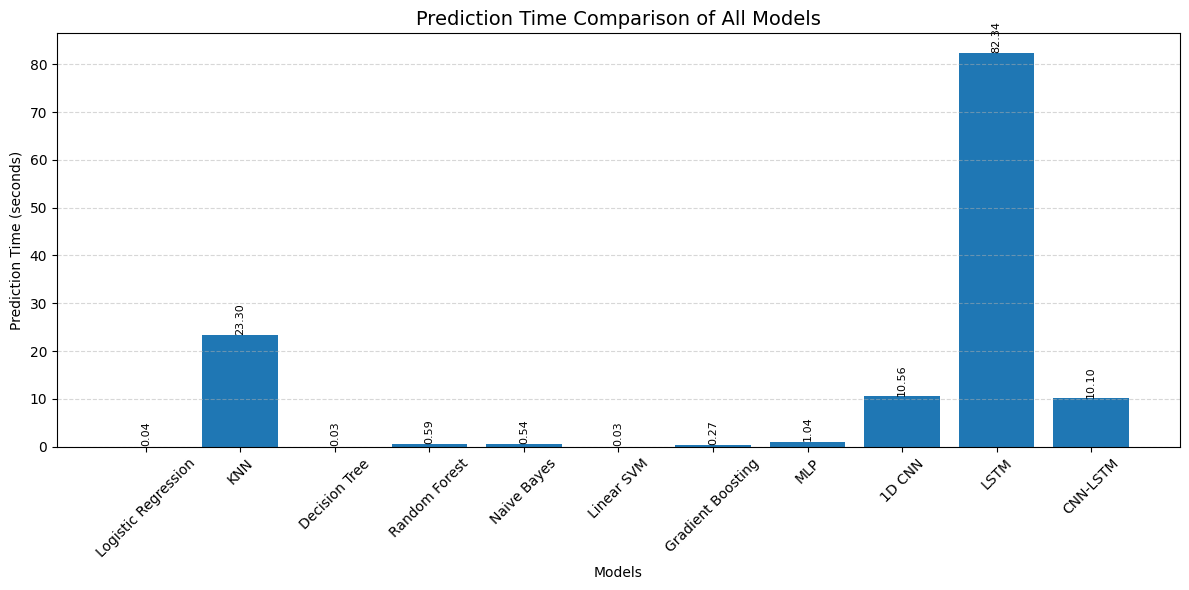

In [70]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    comparison_results["Model"],
    comparison_results["Prediction Time (sec)"]
)

plt.title("Prediction Time Comparison of All Models", fontsize=14)

plt.xlabel("Models")
plt.ylabel("Prediction Time (seconds)")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.2f}",
        ha="center",
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()

In [73]:
import os

print(os.listdir("../reports"))

['cnn_lstm_training_history.csv', 'cnn_training_history.csv', 'decision_tree_depth_search_results.csv', 'final_model_comparison.csv', 'gradient_boosting_n_estimators_search_results.csv', 'knn_neighbor_search_results.csv', 'k_search_results.csv', 'lstm_training_history.csv', 'mlp_training_history.csv', 'naive_bayes_var_smoothing_search_results.csv', 'random_forest_n_estimators_search_results.csv', 'svm_c_search_results.csv']


In [74]:
knn_results_df = pd.read_csv("../reports/knn_neighbor_search_results.csv")

knn_results_df.head()

,n_neighbors,Accuracy,Training Time (sec),Accuracy (%)
0,1,0.863081,0.132004,86.308079
1,3,0.869336,0.156895,86.933619
2,5,0.871312,0.131005,87.131158
3,7,0.868842,0.131000,86.884234
4,9,0.866126,0.111007,86.612618


In [75]:
print("KNN")
print(knn_results_df.columns)

print("\nDecision Tree")
print(pd.read_csv("../reports/decision_tree_depth_search_results.csv").columns)

print("\nRandom Forest")
print(pd.read_csv("../reports/random_forest_n_estimators_search_results.csv").columns)

print("\nGradient Boosting")
print(pd.read_csv("../reports/gradient_boosting_n_estimators_search_results.csv").columns)

print("\nNaive Bayes")
print(pd.read_csv("../reports/naive_bayes_var_smoothing_search_results.csv").columns)

print("\nSVM")
print(pd.read_csv("../reports/svm_c_search_results.csv").columns)

KNN
Index(['n_neighbors', 'Accuracy', 'Training Time (sec)', 'Accuracy (%)'], dtype='object')

Decision Tree
Index(['max_depth', 'Accuracy', 'Training Time (sec)', 'Accuracy (%)'], dtype='object')

Random Forest
Index(['n_estimators', 'Accuracy', 'Training Time (sec)', 'Accuracy (%)'], dtype='object')

Gradient Boosting
Index(['n_estimators', 'Accuracy', 'Training Time (sec)', 'Accuracy (%)'], dtype='object')

Naive Bayes
Index(['var_smoothing', 'Accuracy', 'Training Time (sec)', 'Accuracy (%)'], dtype='object')

SVM
Index(['C', 'Accuracy', 'Training_Time'], dtype='object')


In [76]:
knn_results_df = pd.read_csv("../reports/knn_neighbor_search_results.csv")

dt_results_df = pd.read_csv("../reports/decision_tree_depth_search_results.csv")

rf_results_df = pd.read_csv("../reports/random_forest_n_estimators_search_results.csv")

gb_results_df = pd.read_csv("../reports/gradient_boosting_n_estimators_search_results.csv")

nb_results_df = pd.read_csv("../reports/naive_bayes_var_smoothing_search_results.csv")

svm_results_df = pd.read_csv("../reports/svm_c_search_results.csv")

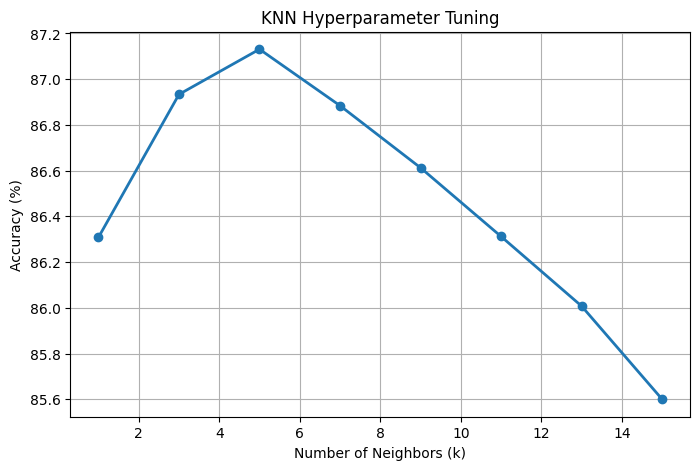

In [77]:
plt.figure(figsize=(8,5))

plt.plot(
    knn_results_df["n_neighbors"],
    knn_results_df["Accuracy (%)"],
    marker="o",
    linewidth=2
)

plt.title("KNN Hyperparameter Tuning")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

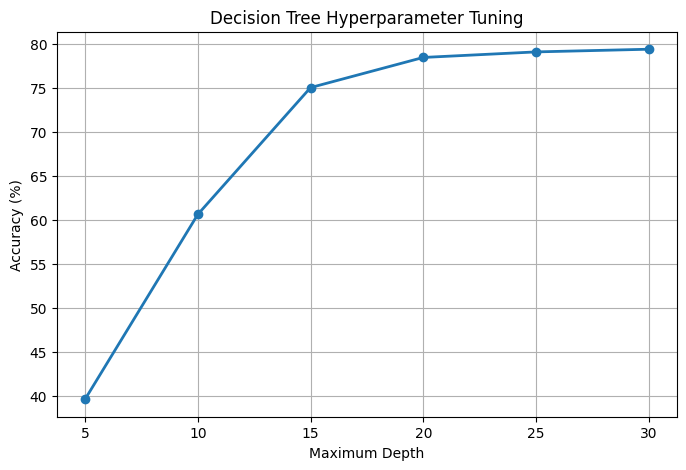

In [78]:
plt.figure(figsize=(8,5))

plt.plot(
    dt_results_df["max_depth"],
    dt_results_df["Accuracy (%)"],
    marker="o",
    linewidth=2
)

plt.title("Decision Tree Hyperparameter Tuning")

plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

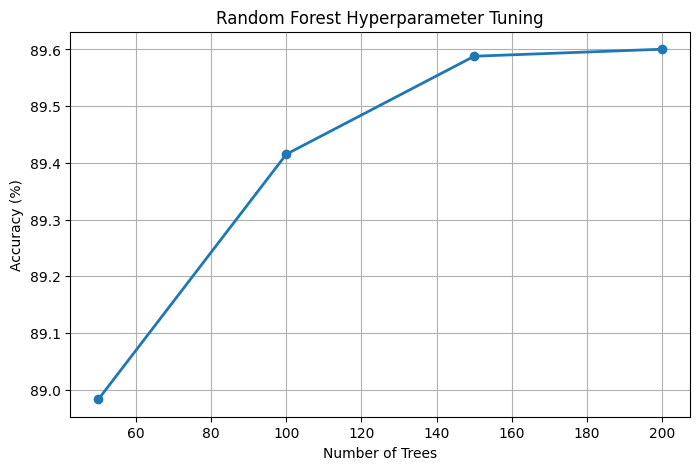

In [79]:
plt.figure(figsize=(8,5))

plt.plot(
    rf_results_df["n_estimators"],
    rf_results_df["Accuracy (%)"],
    marker="o",
    linewidth=2
)

plt.title("Random Forest Hyperparameter Tuning")

plt.xlabel("Number of Trees")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

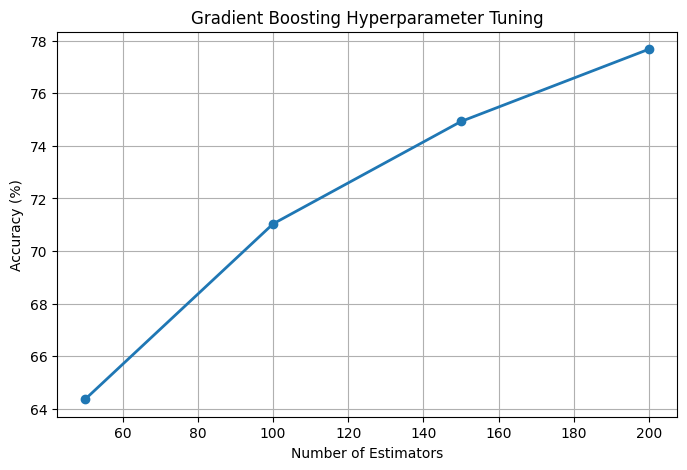

In [80]:
plt.figure(figsize=(8,5))

plt.plot(
    gb_results_df["n_estimators"],
    gb_results_df["Accuracy (%)"],
    marker="o",
    linewidth=2
)

plt.title("Gradient Boosting Hyperparameter Tuning")

plt.xlabel("Number of Estimators")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

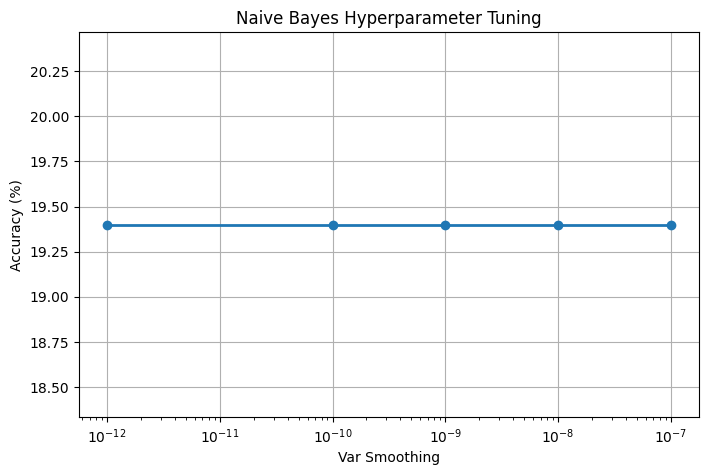

In [81]:
plt.figure(figsize=(8,5))

plt.plot(
    nb_results_df["var_smoothing"],
    nb_results_df["Accuracy (%)"],
    marker="o",
    linewidth=2
)

plt.xscale("log")

plt.title("Naive Bayes Hyperparameter Tuning")

plt.xlabel("Var Smoothing")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

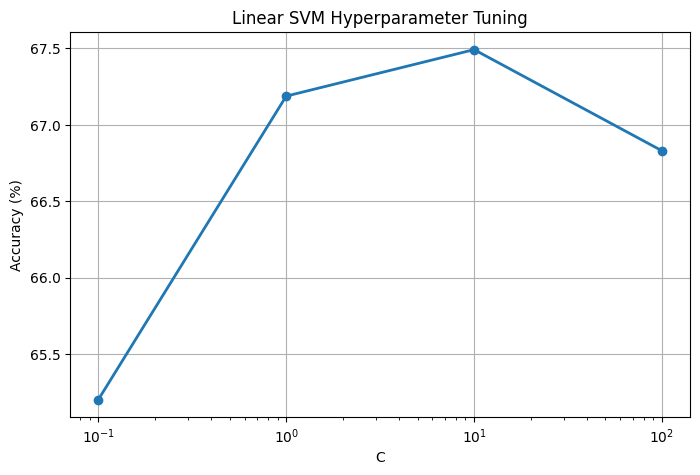

In [82]:
plt.figure(figsize=(8,5))

plt.plot(
    svm_results_df["C"],
    svm_results_df["Accuracy"]*100,
    marker="o",
    linewidth=2
)

plt.xscale("log")

plt.title("Linear SVM Hyperparameter Tuning")

plt.xlabel("C")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

In [53]:
print("selector:", "selector" in globals())
print("label_encoder:", "label_encoder" in globals())
print("scaler:", "scaler" in globals())
print("X_train_selected:", "X_train_selected" in globals())

selector: False
label_encoder: False
scaler: True
X_train_selected: True


In [54]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [55]:
print("anova_selector" in globals())

True


In [56]:
import joblib

joblib.dump(anova_selector, "../models/anova_selector.pkl")

print("ANOVA selector saved successfully!")

ANOVA selector saved successfully!


In [41]:
print(X_test.shape)
print(y_test.shape)

(24299, 204)
(24299,)


In [42]:
import pandas as pd

test_df = pd.DataFrame(X_test)

test_df["Actual_Label"] = y_test

test_df.to_excel("../reports/test_dataset.xlsx", index=False)

print("Test dataset saved successfully!")

C:\Users\devip\AppData\Local\Temp\ipykernel_20196\3687737284.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["Actual_Label"] = y_test


Test dataset saved successfully!
